Import Library & Semak Peranti (Langkah 2)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.11.0+cpu
Device: cpu


Muatkan & Semak Dataset MNIST (Langkah 3)

Training data: 60000
Testing data: 10000
Image shape: torch.Size([1, 28, 28])
Actual label: 7


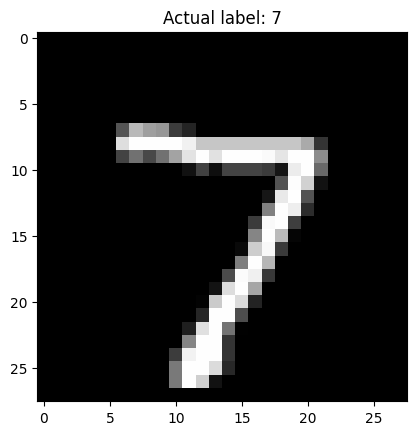

In [ ]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

print(f"Training data: {len(train_dataset)}")
print(f"Testing data: {len(test_dataset)}")

image, label = test_dataset[0]
print(f"Image shape: {image.shape}")
print(f"Actual label: {label}")

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Actual label: {label}")
plt.show()

Bina Model ANN (Langkah 4)

In [ ]:
class ANNModel(nn.Module):
    def __init__(self):
        super(ANNModel, self).__init__()
        self.flatten = nn.Flatten(start_dim=1)
        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

ann_model = ANNModel().to(device)
print(ann_model)

criterion = nn.CrossEntropyLoss()
ann_optimizer = optim.Adam(ann_model.parameters(), lr=0.001)

ANNModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


Latih dan Uji Model ANN (Langkah 5)

In [ ]:
epochs = 2
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        ann_optimizer.zero_grad()
        outputs = ann_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        ann_optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

ann_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = ann_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

ann_accuracy = (correct / total) * 100
print(f"ANN Testing Accuracy: {ann_accuracy:.2f}%")

Epoch 1/2 - Loss: 0.3452
Epoch 2/2 - Loss: 0.1590
ANN Testing Accuracy: 96.32%


Bina Model CNN (Langkah 6)

In [ ]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten(start_dim=1)
        self.fc1 = nn.Linear(16 * 14 * 14, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.flatten(x)
        x = self.fc1(x)
        return x

cnn_model = CNNModel().to(device)
print(cnn_model)

cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

CNNModel(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=10, bias=True)
)


Latih dan Uji Model CNN (Langkah 7)

In [ ]:
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        cnn_optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        cnn_optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

cnn_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

cnn_accuracy = (correct / total) * 100
print(f"CNN Testing Accuracy: {cnn_accuracy:.2f}%")

Epoch 1/2 - Loss: 0.3057
Epoch 2/2 - Loss: 0.1271
CNN Testing Accuracy: 96.78%


Uji Pengecaman 5 Imej Digit (Langkah 8)

Actual: 7
ANN Prediction: 7 [BETUL]
CNN Prediction: 7 [BETUL]


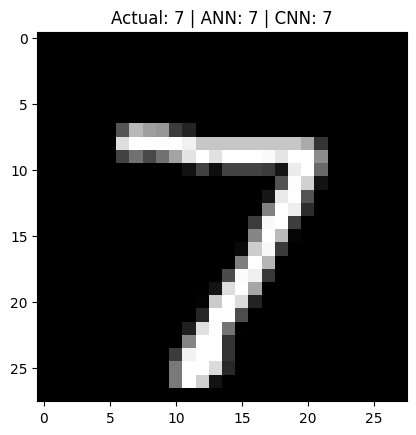

ANN Ramalan Betul: 1 / 5
Actual: 2
ANN Prediction: 2 [BETUL]
CNN Prediction: 2 [BETUL]


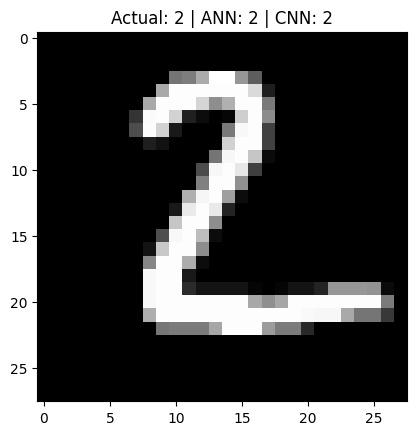

ANN Ramalan Betul: 2 / 5
Actual: 1
ANN Prediction: 1 [BETUL]
CNN Prediction: 1 [BETUL]


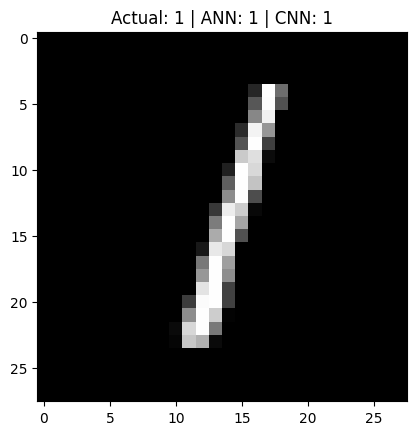

ANN Ramalan Betul: 3 / 5
Actual: 0
ANN Prediction: 0 [BETUL]
CNN Prediction: 0 [BETUL]


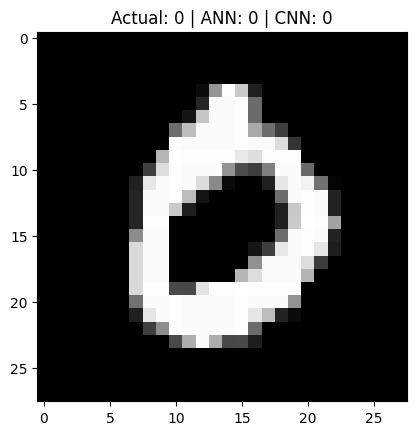

ANN Ramalan Betul: 4 / 5
Actual: 4
ANN Prediction: 4 [BETUL]
CNN Prediction: 4 [BETUL]


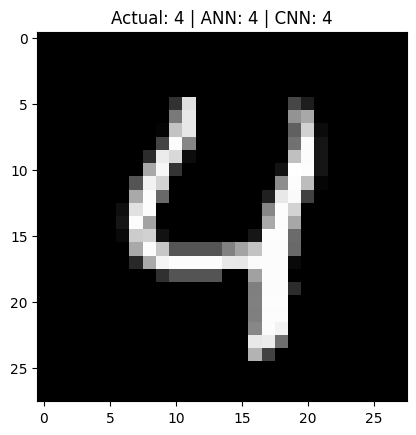

ANN Ramalan Betul: 5 / 5
CNN Ramalan Betul: 5 / 5


In [ ]:
ann_correct_count = 0
cnn_correct_count = 0

for i in range(5):
    img, label = test_dataset[i]
    img_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        ann_pred = ann_model(img_tensor).argmax(dim=1).item()
        cnn_pred = cnn_model(img_tensor).argmax(dim=1).item()

    ann_status = "BETUL" if ann_pred == label else "SALAH"
    cnn_status = "BETUL" if cnn_pred == label else "SALAH"

    if ann_pred == label: ann_correct_count += 1
    if cnn_pred == label: cnn_correct_count += 1

    print(f"Actual: {label}")
    print(f"ANN Prediction: {ann_pred} [{ann_status}]")
    print(f"CNN Prediction: {cnn_pred} [{cnn_status}]")

    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Actual: {label} | ANN: {ann_pred} | CNN: {cnn_pred}")
    plt.show()

    print(f"ANN Ramalan Betul: {ann_correct_count} / 5")
print(f"CNN Ramalan Betul: {cnn_correct_count} / 5")

Bandingkan Keputusan & Analisis (Langkah 9)

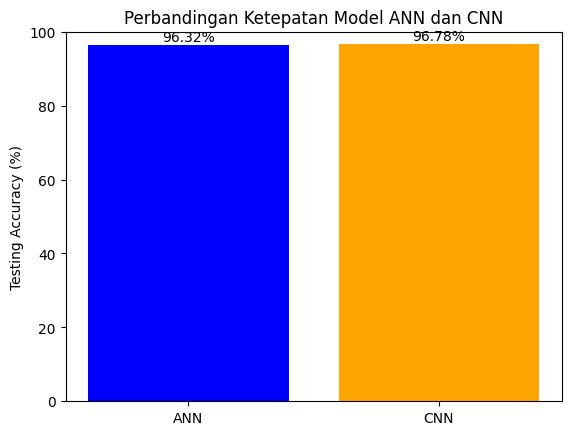

In [ ]:
models = ['ANN', 'CNN']
accuracies = [ann_accuracy, cnn_accuracy]

plt.bar(models, accuracies, color=['blue', 'orange'])
plt.ylabel('Testing Accuracy (%)')
plt.title('Perbandingan Ketepatan Model ANN dan CNN')
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')
plt.ylim(0, 100)
plt.show()